# 01 — Data Cleaning
**Phase 1: Raw Data → Clean Daily Demand Time Series**

**Reads:** `../data/raw/Cleaned_DataSet.csv`

**Writes:**
- `../data/processed/sandwich_daily_demand.csv` (365 rows, full year)
- `../data/processed/sandwich_daily_demand_cleaned.csv` (364 rows, outlier removed)
- `../outputs/figures/daily_demand_timeseries.png`
- `../outputs/figures/feb_outlier_detail.png`

**What this does:**
1. Filters sandwich transactions from the full café dataset
2. Aggregates transaction-level quantities to daily totals
3. Fills missing calendar days with 0 demand
4. Identifies and removes Feb 6, 2023 outlier
5. Saves both full and cleaned daily demand series

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ── Paths (relative to scripts/ folder) ──
RAW_DATA = "../data/raw/Cleaned_DataSet.csv"
OUT_DIR  = "../data/processed"
FIG_DIR  = "../outputs/figures"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

OUTLIER_DATE = "2023-02-06"

## 1. Load and filter sandwich transactions

In [32]:
df = pd.read_csv(RAW_DATA)
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"])
print(f"Raw dataset: {len(df)} transactions, {df['Item'].nunique()} unique items")

sand = df.loc[df["Item"].str.lower() == "sandwich"].copy()
print(f"Sandwich transactions: {len(sand)}")

Raw dataset: 9741 transactions, 10 unique items
Sandwich transactions: 1131


## 2. Aggregate to daily demand and fill missing dates

In [33]:
daily = (
    sand.groupby(sand["Transaction Date"].dt.date)["Quantity"]
    .sum()
    .reset_index()
    .rename(columns={"Transaction Date": "Date", "Quantity": "Daily_Demand"})
)
daily["Date"] = pd.to_datetime(daily["Date"])

# Fill missing calendar days with 0 demand
all_days = pd.date_range(daily["Date"].min(), daily["Date"].max(), freq="D")
daily = (
    daily.set_index("Date")
    .reindex(all_days, fill_value=0)
    .rename_axis("Date")
    .reset_index()
)
print(f"Daily series: {len(daily)} days | {daily['Date'].min().date()} to {daily['Date'].max().date()}")
print(f"Total demand: {daily['Daily_Demand'].sum():.0f}")

# Save full daily demand
daily.to_csv(os.path.join(OUT_DIR, "sandwich_daily_demand.csv"), index=False)
print("Saved: sandwich_daily_demand.csv")

Daily series: 365 days | 2023-01-01 to 2023-12-31
Total demand: 3428
Saved: sandwich_daily_demand.csv


## 3. Plot full time series

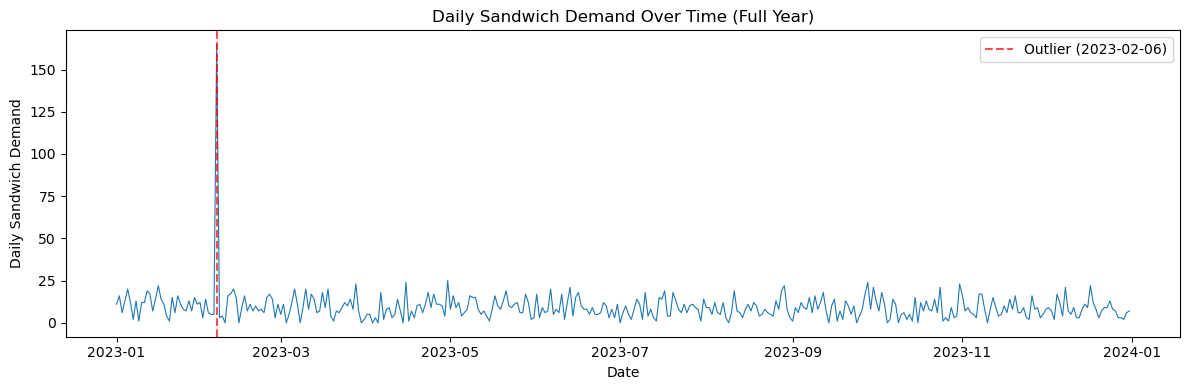

Saved: daily_demand_timeseries.png


In [34]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily["Date"], daily["Daily_Demand"], linewidth=0.8)
ax.axvline(pd.Timestamp(OUTLIER_DATE), color="red", linestyle="--", alpha=0.7, label=f"Outlier ({OUTLIER_DATE})")
ax.set_xlabel("Date")
ax.set_ylabel("Daily Sandwich Demand")
ax.set_title("Daily Sandwich Demand Over Time (Full Year)")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "daily_demand_timeseries.png"), dpi=150)
plt.show()
print("Saved: daily_demand_timeseries.png")

## 4. Remove outlier (Feb 6, 2023)

In [35]:
outlier_ts = pd.Timestamp(OUTLIER_DATE)
outlier_val = daily.loc[daily["Date"] == outlier_ts, "Daily_Demand"].values[0]
daily_clean = daily[daily["Date"] != outlier_ts].copy()
print(f"Outlier removed: {OUTLIER_DATE} (demand = {outlier_val:.0f})")
print(f"Cleaned series: {len(daily_clean)} days")

# Save cleaned daily demand
daily_clean.to_csv(os.path.join(OUT_DIR, "sandwich_daily_demand_cleaned.csv"), index=False)
print("Saved: sandwich_daily_demand_cleaned.csv")

Outlier removed: 2023-02-06 (demand = 165)
Cleaned series: 364 days
Saved: sandwich_daily_demand_cleaned.csv


## 5. Plot February detail (outlier context)

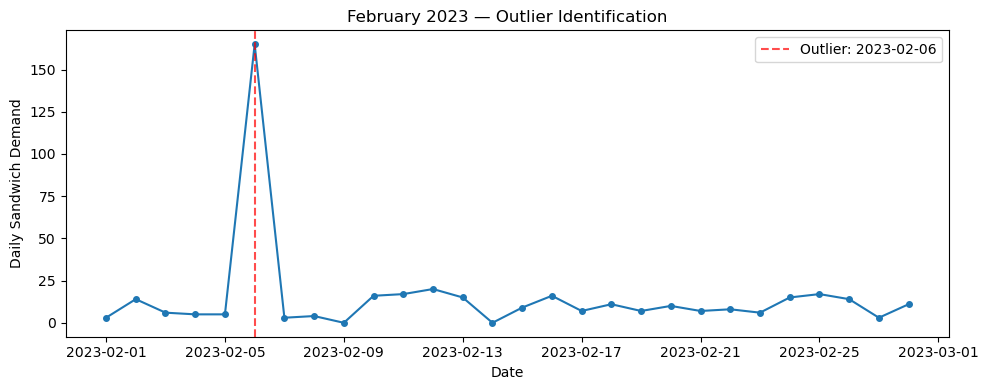

Saved: feb_outlier_detail.png


In [36]:
feb = daily[daily["Date"].dt.month == 2]
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(feb["Date"], feb["Daily_Demand"], marker="o", markersize=4)
ax.axvline(outlier_ts, color="red", linestyle="--", alpha=0.7, label=f"Outlier: {OUTLIER_DATE}")
ax.set_xlabel("Date")
ax.set_ylabel("Daily Sandwich Demand")
ax.set_title("February 2023 — Outlier Identification")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "feb_outlier_detail.png"), dpi=150)
plt.show()
print("Saved: feb_outlier_detail.png")

## 6. Summary statistics

In [37]:
D = daily_clean["Daily_Demand"]
print(f"── Summary Statistics (cleaned) ──")
print(f"  N days:    {len(D)}")
print(f"  Mean:      {D.mean():.2f}")
print(f"  Median:    {D.median():.1f}")
print(f"  Std dev:   {D.std():.2f}")
print(f"  Min:       {D.min():.0f}")
print(f"  Max:       {D.max():.0f}")
print(f"  P95:       {D.quantile(0.95):.0f}")

── Summary Statistics (cleaned) ──
  N days:    364
  Mean:      8.96
  Median:    8.0
  Std dev:   5.58
  Min:       0
  Max:       25
  P95:       19
